In [1]:
import pandas as pd
df=pd.read_csv("Diamonds Prices2022.csv")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.tail()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,53940,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64
53940,53941,0.71,Premium,E,SI1,60.5,55.0,2756,5.79,5.74,3.49
53941,53942,0.71,Premium,F,SI1,59.8,62.0,2756,5.74,5.73,3.43
53942,53943,0.70,Very Good,E,VS2,60.5,59.0,2757,5.71,5.76,3.47


In [5]:
df.shape

(53943, 11)

In [6]:
df.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53943 non-null  int64  
 1   carat       53943 non-null  float64
 2   cut         53943 non-null  object 
 3   color       53943 non-null  object 
 4   clarity     53943 non-null  object 
 5   depth       53943 non-null  float64
 6   table       53943 non-null  float64
 7   price       53943 non-null  int64  
 8   x           53943 non-null  float64
 9   y           53943 non-null  float64
 10  z           53943 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [8]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print(outliers)

       Unnamed: 0  carat        cut color clarity  depth  table  price     x  \
23820       23821   1.17      Ideal     F    VVS1   62.1   57.0  11886  6.82   
23821       23822   2.08      Ideal     I     SI2   62.0   56.0  11886  8.21   
23822       23823   1.70    Premium     I     VS2   62.2   58.0  11888  7.65   
23823       23824   1.09      Ideal     F      IF   61.6   55.0  11888  6.59   
23824       23825   1.68      Ideal     E     SI2   60.4   55.0  11888  7.79   
...           ...    ...        ...   ...     ...    ...    ...    ...   ...   
27745       27746   2.00  Very Good     H     SI1   62.8   57.0  18803  7.95   
27746       27747   2.07      Ideal     G     SI2   62.5   55.0  18804  8.20   
27747       27748   1.51      Ideal     G      IF   61.7   55.0  18806  7.37   
27748       27749   2.00  Very Good     G     SI1   63.5   56.0  18818  7.90   
27749       27750   2.29    Premium     I     VS2   60.8   60.0  18823  8.50   

          y     z  
23820  6.73  4.21  

In [11]:
df = df[(df["price"] >= lower) & (df["price"] <= upper)]

In [12]:
df["price"] = df["price"].clip(lower, upper)

In [14]:

df["cut"].value_counts()



,count
cut,
Ideal,20392
Premium,12535
Very Good,11326
Good,4641
Fair,1509


In [15]:
df["clarity"].value_counts()

,count
clarity,
SI1,12277
VS2,11414
SI2,8214
VS1,7700
VVS2,4848
VVS1,3536
IF,1687
I1,727


In [16]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,50403.000000,50403.000000,50403.000000,50403.000000,50403.000000,50403.000000,50403.000000,50403.000000
mean,27056.475329,0.723656,61.755515,57.421947,3159.436839,5.582975,5.586264,3.448360
std,16103.545012,0.383746,1.430786,2.229478,2764.619785,0.994843,0.993908,0.630403
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,12601.500000,0.380000,61.100000,56.000000,911.000000,4.670000,4.680000,2.880000
50%,28742.000000,0.700000,61.800000,57.000000,2155.000000,5.590000,5.580000,3.430000
75%,41342.500000,1.010000,62.500000,59.000000,4669.000000,6.430000,6.420000,3.980000
max,53943.000000,3.650000,79.000000,79.000000,11883.000000,9.540000,31.800000,31.800000


In [18]:
 df.mean(numeric_only=True)

,0
Unnamed: 0,27056.475329
carat,0.723656
depth,61.755515
table,57.421947
price,3159.436839
x,5.582975
y,5.586264
z,3.448360


In [19]:
df.median(numeric_only=True)

,0
Unnamed: 0,28742.00
carat,0.70
depth,61.80
table,57.00
price,2155.00
x,5.59
y,5.58
z,3.43


In [20]:
df.mode()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.3,Ideal,G,SI1,62.0,56.0,605.0,4.37,4.34,2.7
1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
50398,53939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50399,53940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50400,53941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50401,53942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df.var(numeric_only=True)

,0
Unnamed: 0,2.593242e+08
carat,1.472609e-01
depth,2.047147e+00
table,4.970573e+00
price,7.643123e+06
x,9.897129e-01
y,9.878527e-01
z,3.974085e-01


In [22]:
df.std(numeric_only=True)

,0
Unnamed: 0,16103.545012
carat,0.383746
depth,1.430786
table,2.229478
price,2764.619785
x,0.994843
y,0.993908
z,0.630403


In [23]:
correlation = df.corr(numeric_only=True)

print(correlation)

            Unnamed: 0     carat     depth     table     price         x  \
Unnamed: 0    1.000000 -0.469366 -0.036315 -0.103374 -0.439464 -0.462084   
carat        -0.469366  1.000000  0.046376  0.183679  0.915824  0.980766   
depth        -0.036315  0.046376  1.000000 -0.291954  0.004084 -0.016132   
table        -0.103374  0.183679 -0.291954  1.000000  0.128108  0.193294   
price        -0.439464  0.915824  0.004084  0.128108  1.000000  0.895805   
x            -0.462084  0.980766 -0.016132  0.193294  0.895805  1.000000   
y            -0.459603  0.972892 -0.019471  0.184480  0.891477  0.990768   
z            -0.451805  0.956139  0.115107  0.144515  0.869636  0.965713   

                   y         z  
Unnamed: 0 -0.459603 -0.451805  
carat       0.972892  0.956139  
depth      -0.019471  0.115107  
table       0.184480  0.144515  
price       0.891477  0.869636  
x           0.990768  0.965713  
y           1.000000  0.959671  
z           0.959671  1.000000  


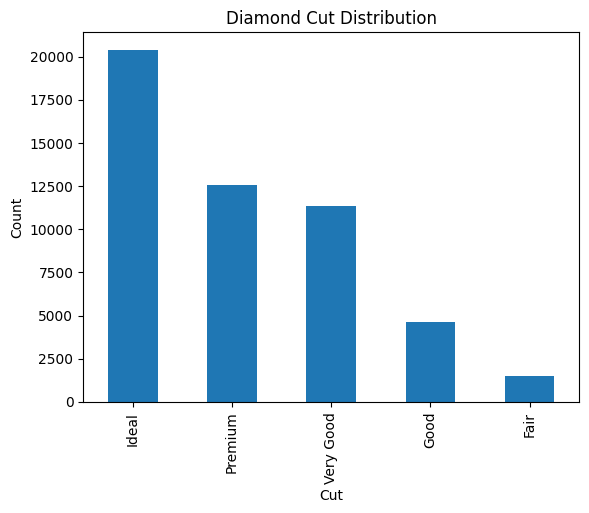

In [24]:
df["cut"].value_counts().plot(kind="bar")

plt.title("Diamond Cut Distribution")
plt.xlabel("Cut")
plt.ylabel("Count")

plt.show()

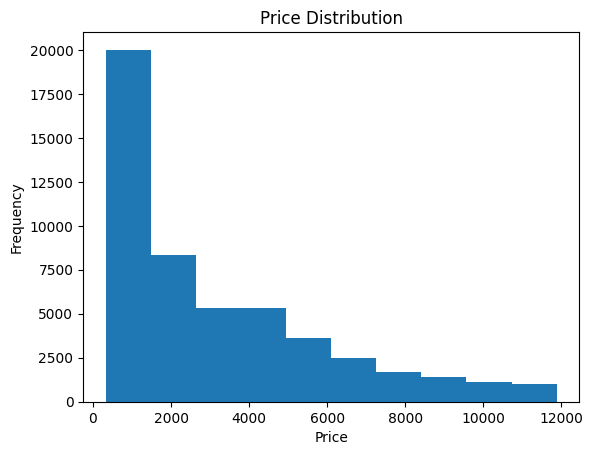

In [25]:
plt.hist(df["price"])

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

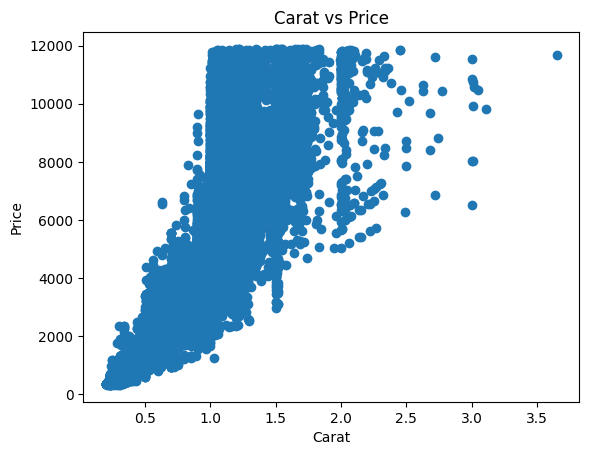

In [26]:
plt.scatter(df["carat"], df["price"])

plt.title("Carat vs Price")
plt.xlabel("Carat")
plt.ylabel("Price")

plt.show()

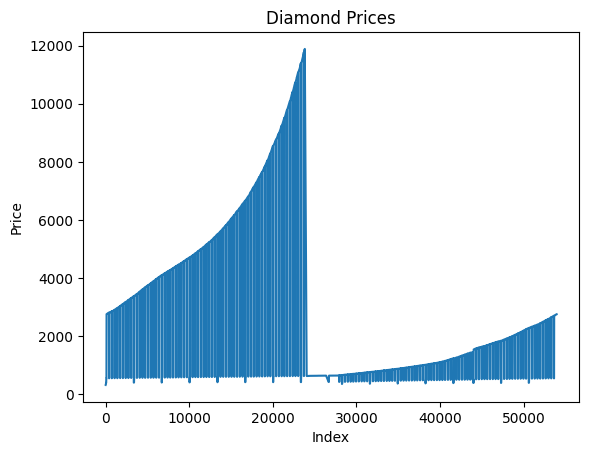

In [27]:
plt.plot(df["price"])

plt.title("Diamond Prices")
plt.xlabel("Index")
plt.ylabel("Price")

plt.show()